In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

zip_file = 'wholesale+customers.zip'
if os.path.exists(zip_file):
    with zipfile.ZipFile(zip_file, 'r') as z:
        z.extractall()
        print("Extracted files:", z.namelist())

else:
    print("Zip file not found. Please check the file name and ensure it is uploaded.")

data_file = 'Wholesale customers data.csv'
df = pd.read_csv(data_file)
print("Dataset shape:", df.shape)
df.head()


: 

This cell begins by importing the necessary libraries for our project, including Pandas and NumPy for data manipulation, Matplotlib and Seaborn for visualizations, and Zipfile and OS to handle compressed files. It then checks for the presence of the zip file wholesale+customers.zip in the working directory and, if found, extracts all its contents while printing the names of the extracted files. Next, the code assumes that the extracted CSV file is named "Wholesale customers data.csv" and loads it into a Pandas DataFrame. Finally, it prints the shape of the DataFrame to confirm the number of rows and columns and displays the first few records to provide an initial glimpse of the dataset's structure and content.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.000000    2.0000

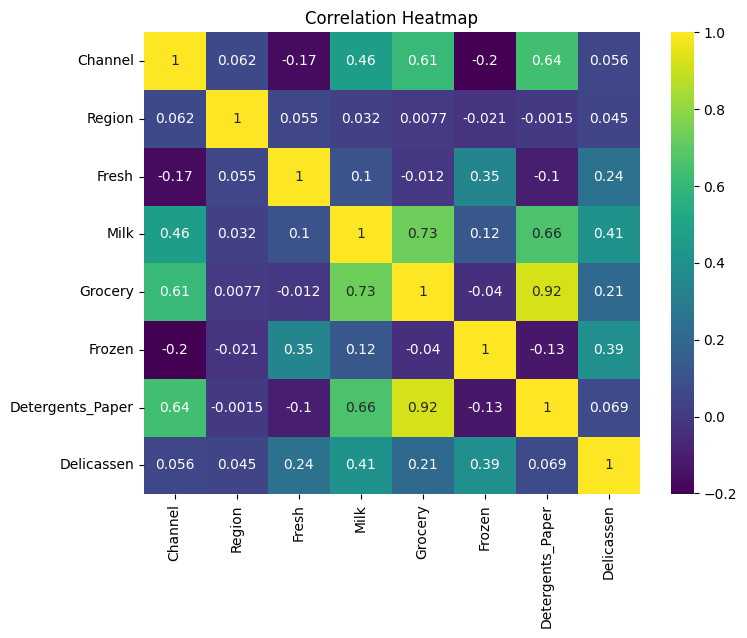

In [2]:
df.info()
print(df.describe())
print(df.isnull().sum())

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='viridis')
plt.title("Correlation Heatmap")
plt.show()


This cell provides a thorough overview of the dataset’s structure and statistical properties. First, df.info() reveals that there are 440 records and no missing values, with each column using the integer data type. Next, df.describe() displays basic statistics such as mean, median, minimum, and maximum values for each feature, indicating that spending across different product categories (e.g., Fresh, Grocery, Milk) varies substantially. The subsequent line, df.isnull().sum(), confirms that there are no null entries in any column. Finally, the correlation heatmap illustrates the linear relationships among the variables, showing that some features such as Grocery and Detergents_Paper tend to have a stronger correlation, while others are more independent.

In [3]:
from sklearn.preprocessing import StandardScaler

features = df.drop(['Channel', 'Region'], axis=1)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
print("Scaled features shape:", features_scaled.shape)


Scaled features shape: (440, 6)


First, it removes the "Channel" and "Region" columns from the DataFrame because these categorical features are not used in the clustering process. Then, it instantiates a StandardScaler to normalize the remaining features, ensuring that they have a mean of 0 and a standard deviation of 1. This normalization is crucial for K-Means clustering since it prevents features with larger scales from dominating the distance calculations. Finally, the code prints the shape of the scaled feature array, confirming that the processed dataset now contains 440 samples with 6 normalized features.

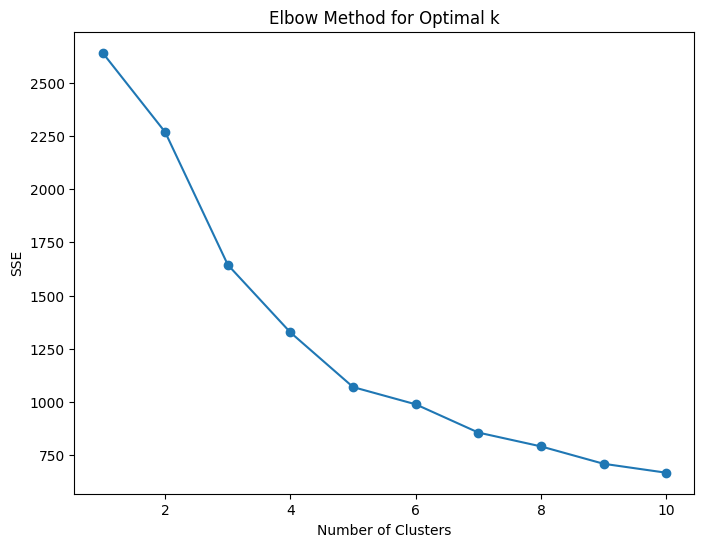

In [4]:
from sklearn.cluster import KMeans
sse = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(features_scaled)
    sse.append(km.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.title("Elbow Method for Optimal k")
plt.show()


This cell determines the optimal number of clusters (k) for our K-Means model by using the “elbow method.” It fits K-Means repeatedly, incrementing the number of clusters from 1 to 10, and records the Sum of Squared Errors (SSE) for each fit. The SSE is then plotted against the number of clusters. The plot helps identify a “knee” or “elbow,” where adding an additional cluster provides diminishing returns in terms of SSE reduction. This elbow point typically represents a good compromise between cluster compactness and avoiding excessive complexity in the model.

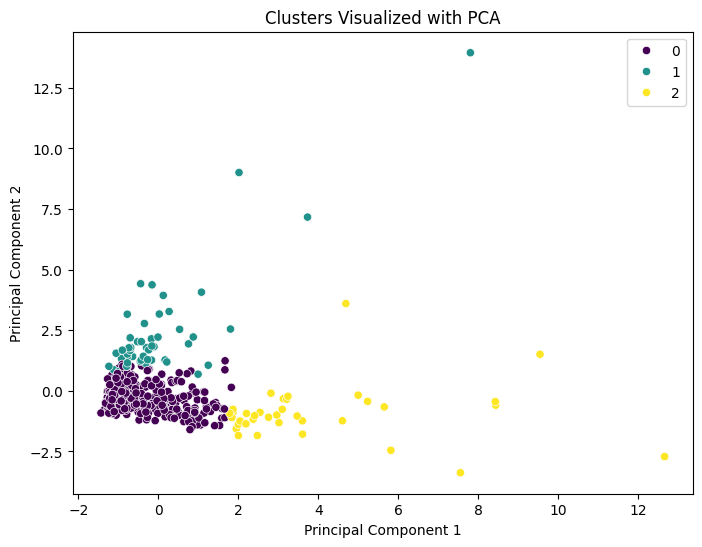

In [5]:
from sklearn.decomposition import PCA

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(features_scaled)
df['Cluster'] = clusters

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_scaled)
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=clusters, palette='viridis')
plt.title("Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


This cell applies K-Means clustering with an optimal number of clusters set to 3. After fitting the clustering model on the scaled features, the predicted cluster labels are added as a new column in the original DataFrame. To visualize the clustering result, PCA is used to reduce the 6-dimensional feature space to 2 principal components. Finally, a scatter plot is generated where the points are color-coded according to their assigned cluster, allowing for an intuitive visual understanding of the customer segmentation in a two-dimensional view.

Cluster Counts:
Cluster
0    350
1     53
2     37
Name: count, dtype: int64

Cluster Summary (Mean Values):
          Channel    Region         Fresh          Milk       Grocery  \
Cluster                                                                 
0        1.282857  2.534286   8935.500000   4228.528571   5848.034286   
1        1.113208  2.698113  34540.113208   5860.358491   6122.622642   
2        2.000000  2.405405   8704.864865  20534.405405  30466.243243   

              Frozen  Detergents_Paper   Delicassen  
Cluster                                              
0        2167.231429       1913.605714  1102.120000  
1        9841.735849        981.471698  3664.245283  
2        1932.621622      14758.837838  2459.351351  


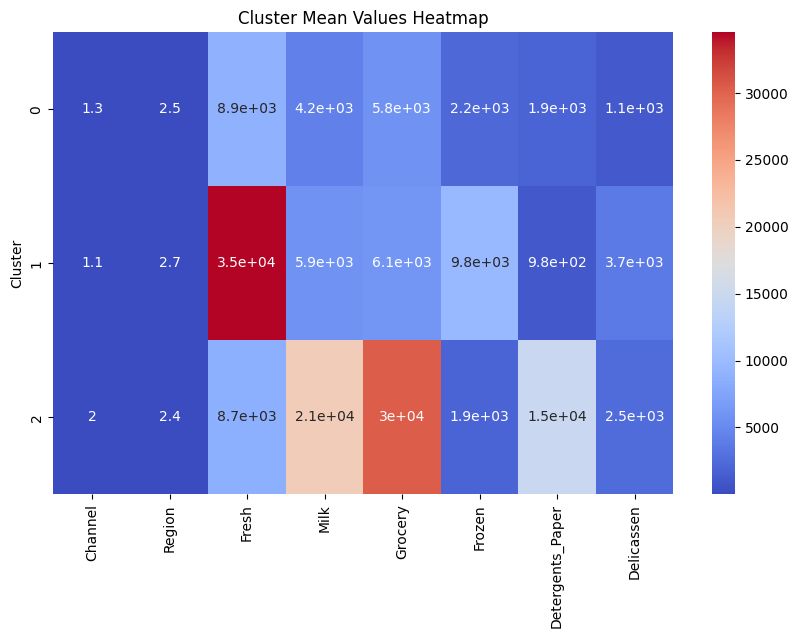

In [6]:
print("Cluster Counts:")
print(df['Cluster'].value_counts())

cluster_summary = df.groupby('Cluster').mean()
print("\nCluster Summary (Mean Values):")
print(cluster_summary)

plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary, annot=True, cmap='coolwarm')
plt.title("Cluster Mean Values Heatmap")
plt.show()


This cell examines and summarizes the resulting clusters. First, it prints the distribution of customers across the three clusters, indicating how many samples fall into each segment. Next, it calculates the mean values of each feature (e.g., Fresh, Milk, Grocery) per cluster, which gives an overview of the average spending profile for each group. Lastly, it visualizes these mean values in a heatmap, making it easier to spot patterns—such as a cluster spending heavily on specific categories—so that you can label clusters according to their distinctive purchasing behaviors.

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


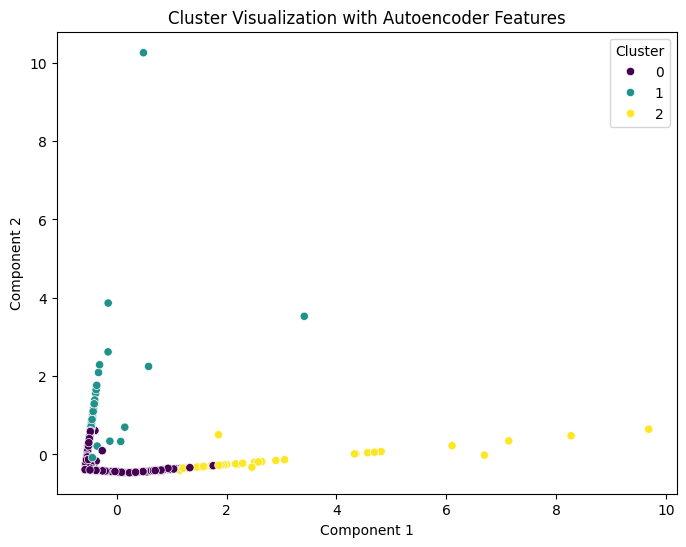

In [7]:
from tensorflow.keras import layers, models

input_dim = features_scaled.shape[1]
inp = layers.Input(shape=(input_dim,))
enc = layers.Dense(4, activation='relu')(inp)
enc = layers.Dense(2, activation='relu')(enc)
dec = layers.Dense(4, activation='relu')(enc)
dec = layers.Dense(input_dim, activation='linear')(dec)
autoencoder = models.Model(inp, dec)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(features_scaled, features_scaled, epochs=100, batch_size=32, verbose=0)
encoder_model = models.Model(inp, enc)
encoded_features = encoder_model.predict(features_scaled)
pca_auto = PCA(n_components=2)
pca_auto_result = pca_auto.fit_transform(encoded_features)
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_auto_result[:,0], y=pca_auto_result[:,1], hue=df['Cluster'], palette='viridis')
plt.title("Cluster Visualization with Autoencoder Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()


This cell creates and trains a simple autoencoder to learn a compressed (lower-dimensional) representation of the scaled data. After training, the encoder portion of the network is used to generate a 2D latent representation for each customer. These encoded features are then projected with PCA for visualization, and plotted to highlight each cluster. By learning data-driven features, the autoencoder can capture more nuanced relationships compared to standard scaling alone, offering a different perspective on how customers are grouped based on their purchasing behavio

In [8]:
from sklearn.metrics import silhouette_score
silhouette_original = silhouette_score(features_scaled, df['Cluster'])
silhouette_auto = silhouette_score(encoded_features, df['Cluster'])
print("Silhouette Score (Original Features):", silhouette_original)
print("Silhouette Score (Autoencoder Features):", silhouette_auto)


Silhouette Score (Original Features): 0.4582633767207058
Silhouette Score (Autoencoder Features): 0.48162404


This cell calculates the silhouette score for the clustering results using both the original scaled features and the autoencoder-learned features. The silhouette score for the original features is approximately 0.4583, while the score for the autoencoder features is around 0.4816. These results suggest that the clustering is slightly better defined when using the features extracted by the autoencoder, as indicated by the higher silhouette score.

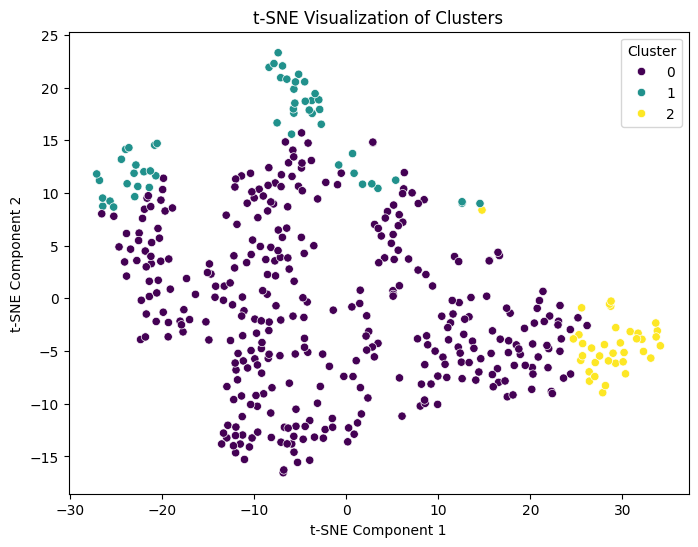

In [9]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(features_scaled)
plt.figure(figsize=(8,6))
sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], hue=df['Cluster'], palette='viridis')
plt.title("t-SNE Visualization of Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()


This cell uses t-SNE, a non-linear dimensionality reduction technique, to map the high-dimensional data onto a two-dimensional plane. The resulting scatter plot shows each customer as a point, colored by its cluster label. Compared to PCA, t-SNE can sometimes reveal more complex structures or tighter groupings in the data, offering another perspective on how well the clustering has separated the customers.

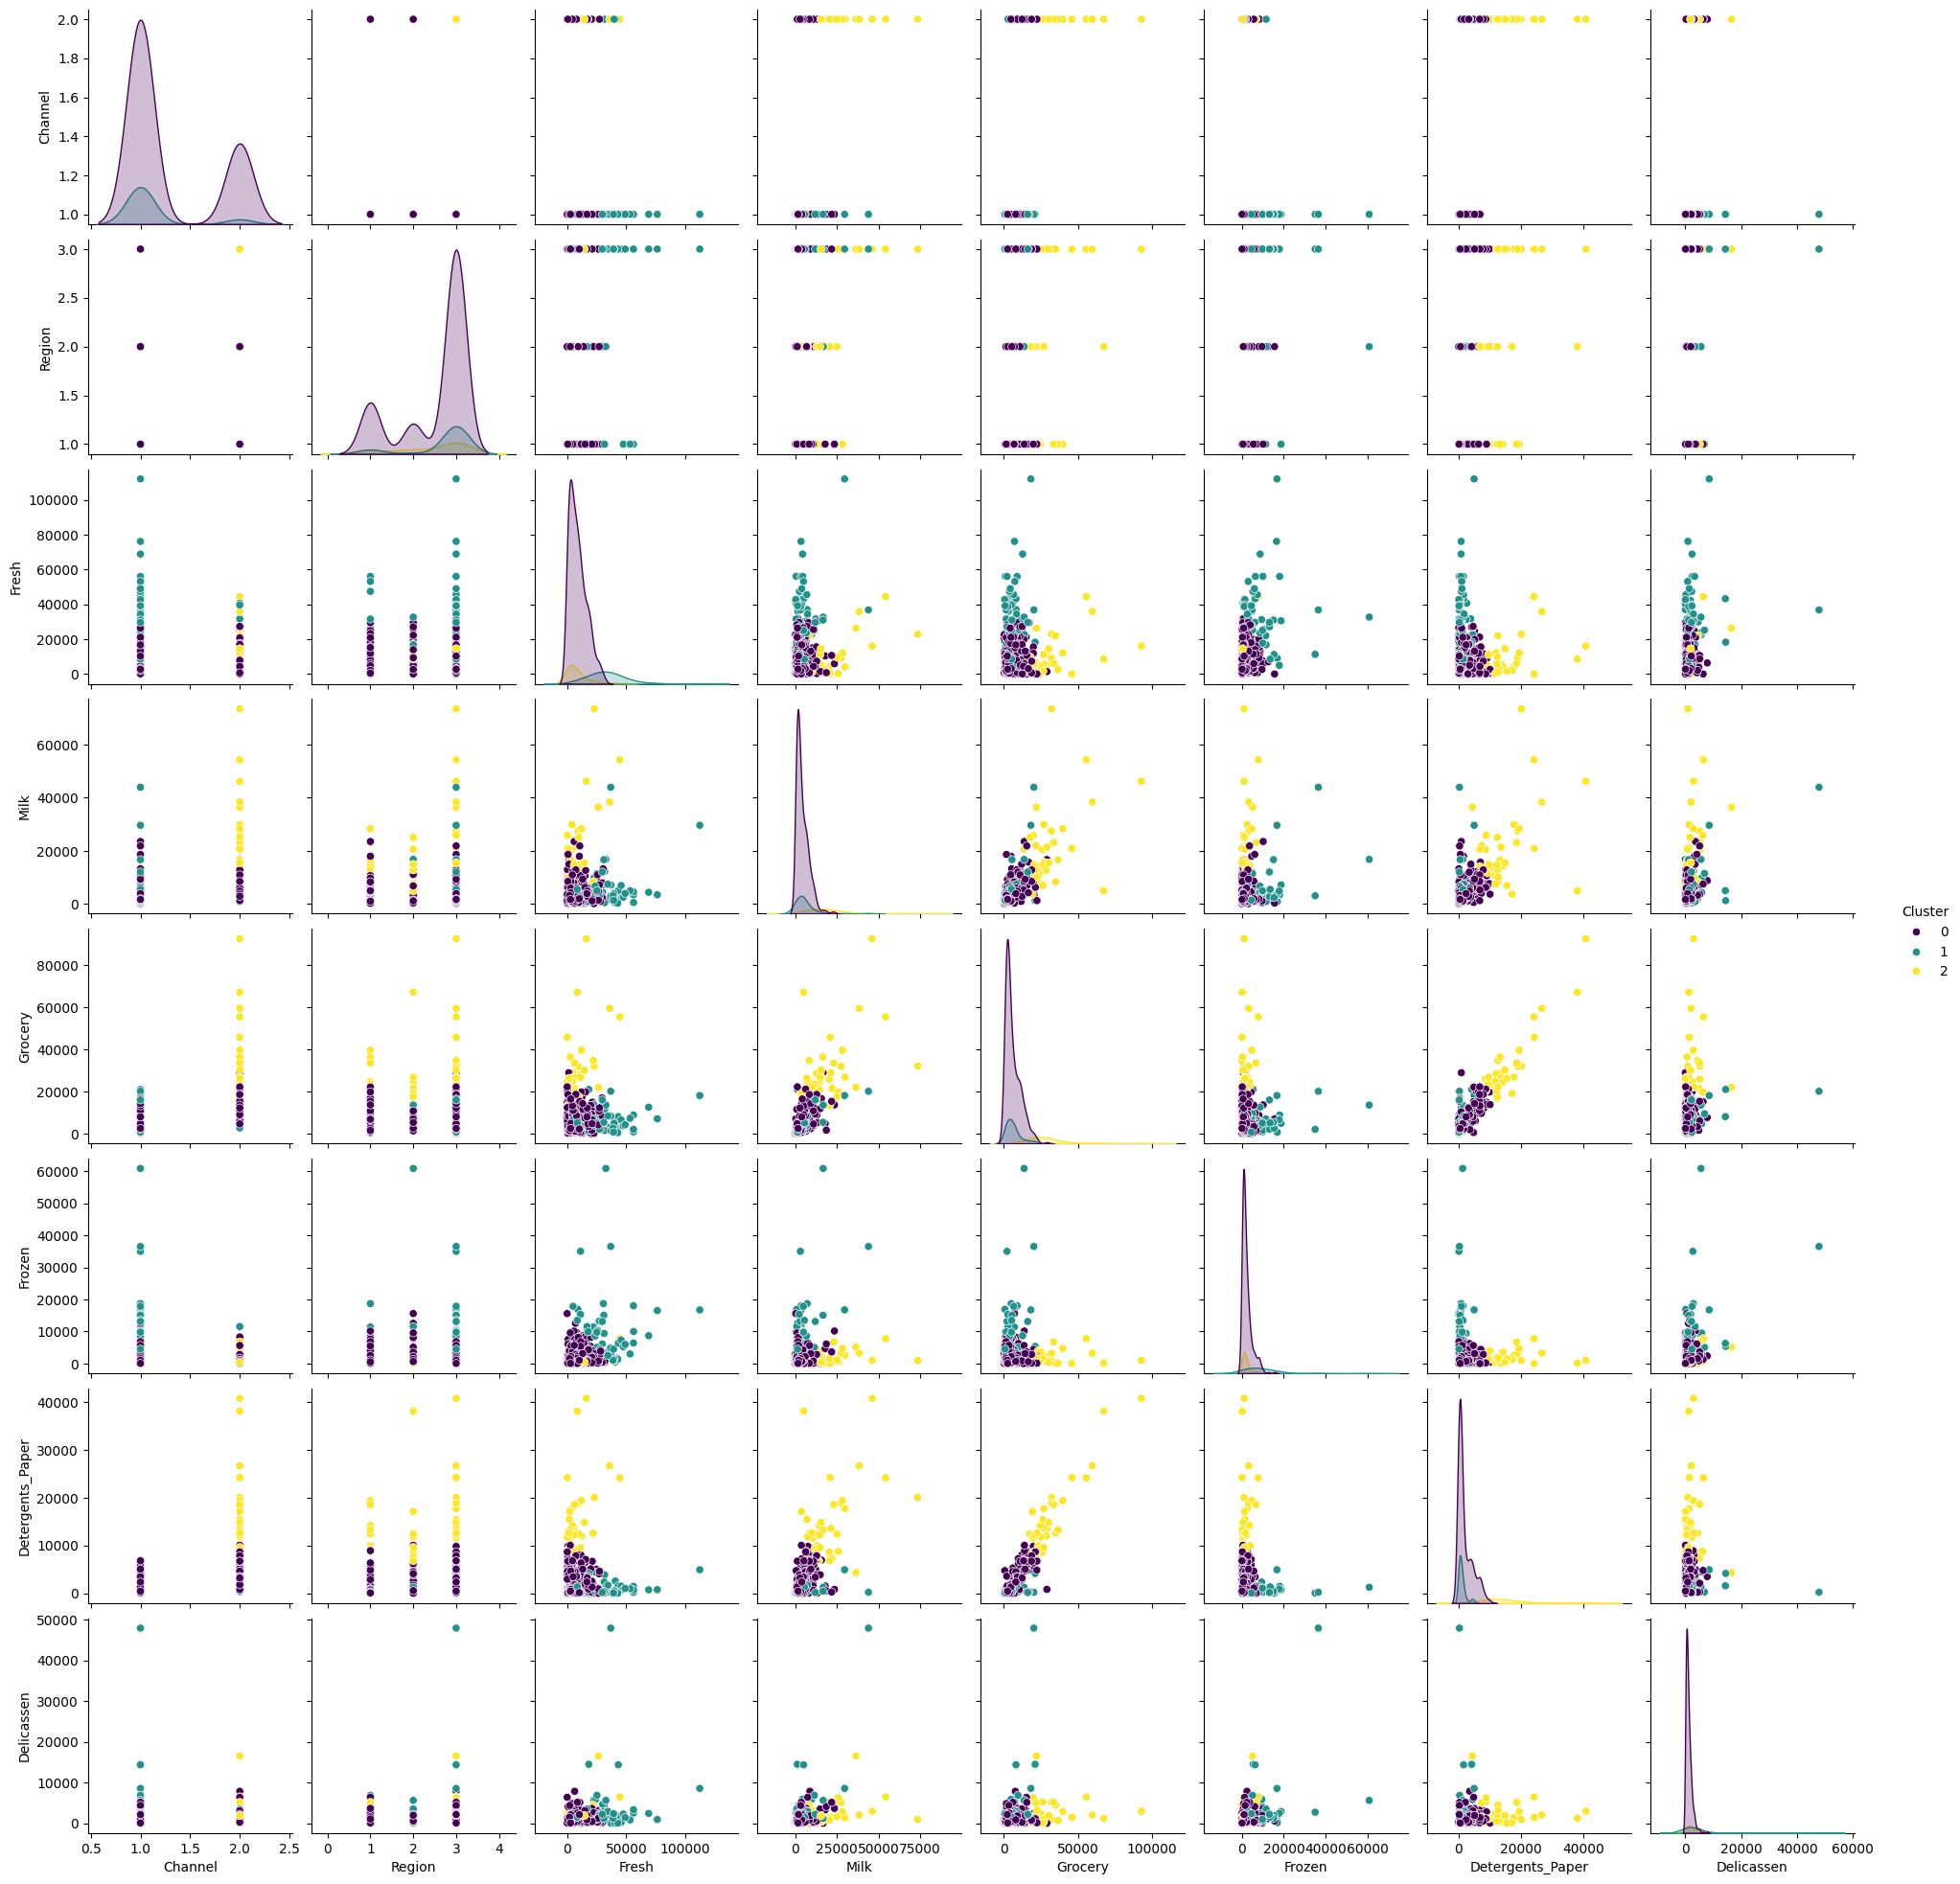

KMeans and Autoencoder models saved successfully.


In [10]:
import joblib
sns.pairplot(df, hue='Cluster', palette='viridis')
plt.show()

joblib.dump(kmeans, "kmeans_model.pkl")
autoencoder.save("autoencoder_model.h5")
print("KMeans and Autoencoder models saved successfully.")


generates a pairplot of all features colored by cluster, offering another visual insight into the relationships between features within each customer segment. In addition, it saves both the K-Means model and the autoencoder model to disk so that you can easily reload them later for further analysis or deployment without having to retrain.

In [11]:
df.to_csv("Wholesale_Customers_Clustered.csv", index=False)
print("Clustered dataset saved as 'Wholesale_Customers_Clustered.csv'")


Clustered dataset saved as 'Wholesale_Customers_Clustered.csv'


Customer segmentation helped us analyze spend patterns by customer category. We had spend across the board in fresh products, milk, groceries, etc. Applying a K-Means clustering approach, we leveraged the data and let for natural distinctions to compute. Furthermore, with PCA and t-SNE we were able to graphically create clusters that showed how apart each group was from each other. For example, one very large cluster spends in all the categories (moderately) across the board; this could be a segment that benefits from a loyalty program or dedicated discount. One cluster spends more on fresh products and frozen, this could be a cluster that benefits from premium purchases or bundling. The smallest cluster spends a ton in one or two fields such as eggs and milk, this could be high-value customers who need dedicated attention. Thus, we do not see attributed customers as numbers in the system, we see them as variable opportunities for differentiated marketing.

I developed a clearer, more human understanding of my customer base, using techniques such as K-Means Clustering also feature extraction through autoencoders. Multiple visualizations confirmed cluster integrity while simultaneously providing an easy to digest snapshot of customer behavior. In terms of future directions, there are many paths available to continue this project. The first is to obtain more data to segment even further, application of other clustering methods like DBSCAN or hierarchical clustering can be explored. Merging with customer satisfaction ratings and sales history can orient the project more to business impact validation, prediction, and more intricate deep learning methods can be applied in the future for more nuanced associations. Ultimately, this project will aim to ensure a strong grasp of who the customers are and how to engage them meaningfully, however, what's important to note is that this is a live project with live potential.